In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
df = pd.read_csv('/kaggle/input/kepler-exoplanet-discovery-ml-challenge-v/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7173 entries, 0 to 7172
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              7173 non-null   int64  
 1   kepoi_name         7173 non-null   object 
 2   kepler_name        1720 non-null   object 
 3   koi_pdisposition   7173 non-null   object 
 4   koi_score          6025 non-null   float64
 5   koi_fpflag_nt      7173 non-null   int64  
 6   koi_fpflag_ss      7173 non-null   int64  
 7   koi_fpflag_co      7173 non-null   int64  
 8   koi_fpflag_ec      7173 non-null   int64  
 9   koi_period         7173 non-null   float64
 10  koi_period_err1    6825 non-null   float64
 11  koi_period_err2    6825 non-null   float64
 12  koi_time0bk        7173 non-null   float64
 13  koi_time0bk_err1   6825 non-null   float64
 14  koi_time0bk_err2   6825 non-null   float64
 15  koi_impact         6898 non-null   float64
 16  koi_impact_err1    6825 

In [4]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (44): ['kepid', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']

Categorical columns (5): ['kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_tce_delivname', 'koi_disposition']


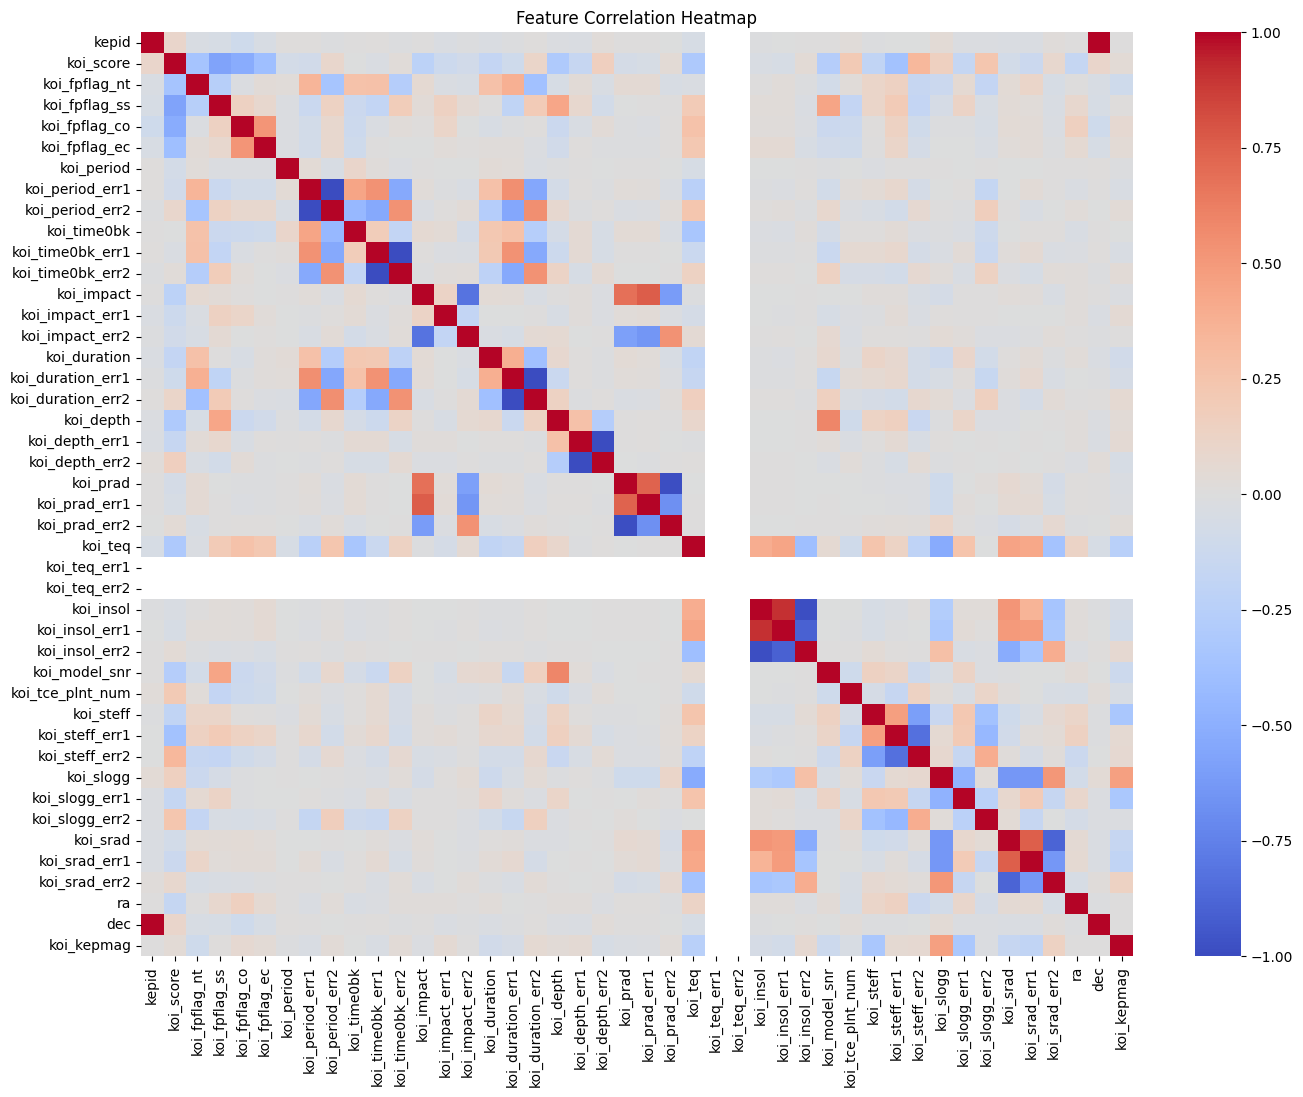

In [6]:
# Select numerical features only (exclude id columns if needed)
numeric_df = df.select_dtypes(include='number')
# Compute the correlation matrix
corr = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


In [8]:
# Load and filter data
df = pd.read_csv('/kaggle/input/kepler-exoplanet-discovery-ml-challenge-v/train.csv')
df_filtered = df[df['koi_pdisposition'] != 'FALSE POSITIVE'].copy()
df_filtered = df_filtered.dropna(subset=['koi_score'])

# 1. koi_score == 1.0
mask_score_1 = df_filtered['koi_score'] == 1.0
eq_df_1 = df_filtered[mask_score_1 & (df_filtered['koi_pdisposition'] == df_filtered['koi_disposition'])]
neq_df_1 = df_filtered[mask_score_1 & (df_filtered['koi_pdisposition'] != df_filtered['koi_disposition'])]

print(f"With koi_score == 1.0 and koi_pdisposition == koi_disposition: {len(eq_df_1)}")
print("First 5 matching rows:")
print(eq_df_1[['koi_pdisposition', 'koi_disposition', 'koi_score']].head())

print(f"With koi_score == 1.0 and koi_pdisposition != koi_disposition: {len(neq_df_1)}")
print("First 5 non-matching rows:")
print(neq_df_1[['koi_pdisposition', 'koi_disposition', 'koi_score']].head())

# 2. koi_score != 1.0
mask_score_not_1 = df_filtered['koi_score'] != 1.0
eq_df_n1 = df_filtered[mask_score_not_1 & (df_filtered['koi_pdisposition'] == df_filtered['koi_disposition'])]
neq_df_n1 = df_filtered[mask_score_not_1 & (df_filtered['koi_pdisposition'] != df_filtered['koi_disposition'])]

print(f"With koi_score != 1.0 and koi_pdisposition == koi_disposition: {len(eq_df_n1)}")
print("First 5 matching rows:")
print(eq_df_n1[['koi_pdisposition', 'koi_disposition', 'koi_score']].head())

print(f"With koi_score != 1.0 and koi_pdisposition != koi_disposition: {len(neq_df_n1)}")
print("First 5 non-matching rows:")
print(neq_df_n1[['koi_pdisposition', 'koi_disposition', 'koi_score']].head())


With koi_score == 1.0 and koi_pdisposition == koi_disposition: 376
First 5 matching rows:
    koi_pdisposition koi_disposition  koi_score
65         CANDIDATE       CANDIDATE        1.0
72         CANDIDATE       CANDIDATE        1.0
80         CANDIDATE       CANDIDATE        1.0
87         CANDIDATE       CANDIDATE        1.0
112        CANDIDATE       CANDIDATE        1.0
With koi_score == 1.0 and koi_pdisposition != koi_disposition: 947
First 5 non-matching rows:
   koi_pdisposition koi_disposition  koi_score
0         CANDIDATE       CONFIRMED        1.0
2         CANDIDATE       CONFIRMED        1.0
14        CANDIDATE       CONFIRMED        1.0
24        CANDIDATE       CONFIRMED        1.0
27        CANDIDATE       CONFIRMED        1.0
With koi_score != 1.0 and koi_pdisposition == koi_disposition: 959
First 5 matching rows:
   koi_pdisposition koi_disposition  koi_score
10        CANDIDATE       CANDIDATE      0.809
11        CANDIDATE       CANDIDATE      0.960
12        CANDI

In [9]:
train_df = pd.read_csv('/kaggle/input/kepler-exoplanet-discovery-ml-challenge-v/train.csv')
test_df = pd.read_csv('/kaggle/input/kepler-exoplanet-discovery-ml-challenge-v/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTarget distribution:\n{train_df['koi_disposition'].value_counts()}")

Training data shape: (7173, 49)
Test data shape: (2391, 49)

Target distribution:
koi_disposition
FALSE POSITIVE    3773
CONFIRMED         1719
CANDIDATE         1681
Name: count, dtype: int64


In [10]:
train_df.drop(columns=['kepler_name', 'kepoi_name', 'kepid', 'koi_tce_delivname'], inplace=True)

# Drop uncertainty columns (columns with '_err1' or '_err2' in name)
uncertainty_cols = [col for col in train_df.columns if '_err1' in col or '_err2' in col]
print(f"\nDropping {len(uncertainty_cols)} uncertainty columns")
train_df = train_df.drop(columns=uncertainty_cols)

# Drop NaN values
print(f"\nBefore dropping NaNs: {train_df.shape}")
train_df = train_df.dropna()
print(f"After dropping NaNs: {train_df.shape}")

# Save target before preprocessing
y_target = train_df['koi_disposition'].copy()



Dropping 22 uncertainty columns

Before dropping NaNs: (7173, 23)
After dropping NaNs: (5976, 23)


In [11]:
# 1. FALSE POSITIVE FLAG AGGREGATION
# If ANY of the 4 FP flags is 1, it's a strong indicator of FALSE POSITIVE
fp_flag_cols = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

# Create aggregated FP flag feature
train_df['ANY_FP_FLAG'] = train_df[fp_flag_cols].max(axis=1)
train_df['FP_FLAG_COUNT'] = train_df[fp_flag_cols].sum(axis=1)

print(f"Samples with ANY FP flag = 1: {train_df['ANY_FP_FLAG'].sum()}")
print(f"  - Of these, actual FALSE POSITIVE: {(train_df[train_df['ANY_FP_FLAG']==1]['koi_disposition']=='FALSE POSITIVE').sum()}")


Samples with ANY FP flag = 1: 2993
  - Of these, actual FALSE POSITIVE: 2931


In [12]:
# 2. DISPOSITION SCORE FEATURE
# koi_score = 1 is a strong indicator that CANDIDATE -> CONFIRMED
if 'koi_score' in train_df.columns:
    train_df['HIGH_DISPOSITION_SCORE'] = (train_df['koi_score'] == 1.0).astype(int)
    print(f"\nSamples with koi_score = 1: {train_df['HIGH_DISPOSITION_SCORE'].sum()}")
    
    # Check correlation with CONFIRMED among non-FP
    non_fp_df = train_df[train_df['koi_disposition'] != 'FALSE POSITIVE']
    if len(non_fp_df) > 0:
        confirmed_with_high_score = ((non_fp_df['HIGH_DISPOSITION_SCORE']==1) & 
                                     (non_fp_df['koi_disposition']=='CONFIRMED')).sum()
        total_high_score = non_fp_df['HIGH_DISPOSITION_SCORE'].sum()
        if total_high_score > 0:
            print(f"  - Among high score non-FP: {confirmed_with_high_score}/{total_high_score} are CONFIRMED ({confirmed_with_high_score/total_high_score*100:.1f}%)")



Samples with koi_score = 1: 1321
  - Among high score non-FP: 947/1321 are CONFIRMED (71.7%)


In [13]:
# 3. INTERACTION FEATURES
# Create interaction between FP flags and disposition score
if 'koi_score' in train_df.columns:
    train_df['FP_FLAG_SCORE_INTERACTION'] = train_df['ANY_FP_FLAG'] * (1 - train_df['koi_score'])

print("\nFeature engineering completed")

# One-hot encode categorical columns
train_df = pd.get_dummies(train_df, columns=['koi_pdisposition'], prefix='koi_pdisposition')

# Separate features from target
X_train = train_df.drop(columns=['koi_disposition'])
y_train = train_df['koi_disposition']

print(f"\nFinal training features shape: {X_train.shape}")
print(f"Features: {list(X_train.columns)}")



Feature engineering completed

Final training features shape: (5976, 27)
Features: ['koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag', 'ANY_FP_FLAG', 'FP_FLAG_COUNT', 'HIGH_DISPOSITION_SCORE', 'FP_FLAG_SCORE_INTERACTION', 'koi_pdisposition_CANDIDATE', 'koi_pdisposition_FALSE POSITIVE']


In [14]:
# Stage 1: FALSE POSITIVE vs NOT FALSE POSITIVE
y_train_fp = (y_train == 'FALSE POSITIVE').astype(int)
print(f"\nStage 1 - FALSE POSITIVE: {y_train_fp.sum()}, NOT FP: {(~y_train_fp.astype(bool)).sum()}")

# Stage 2: CANDIDATE vs CONFIRMED (only for non-false positives)
non_fp_mask = y_train != 'FALSE POSITIVE'
X_train_stage2 = X_train[non_fp_mask]
y_train_stage2 = (y_train[non_fp_mask] == 'CONFIRMED').astype(int)
print(f"Stage 2 - CONFIRMED: {y_train_stage2.sum()}, CANDIDATE: {(~y_train_stage2.astype(bool)).sum()}")


Stage 1 - FALSE POSITIVE: 2931, NOT FP: 3045
Stage 2 - CONFIRMED: 1712, CANDIDATE: 1333


In [15]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_train_stage2_scaled = X_train_scaled[non_fp_mask]

In [16]:
# Split for validation
X_train_fp, X_val_fp, y_train_fp_split, y_val_fp = train_test_split(
    X_train_scaled, y_train_fp, test_size=0.2, random_state=42, stratify=y_train_fp
)

# Models to test
models_stage1 = {
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_estimators=200),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, iterations=200),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results_stage1 = {}

print("\nTraining and evaluating models...")
for name, model in models_stage1.items():
    print(f"\n{name}:")
    model.fit(X_train_fp, y_train_fp_split)
    y_pred = model.predict(X_val_fp)
    
    acc = accuracy_score(y_val_fp, y_pred)
    f1 = f1_score(y_val_fp, y_pred, average='weighted')
    
    results_stage1[name] = {'model': model, 'accuracy': acc, 'f1_score': f1}
    
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")

# Select best model
best_model_fp_name = max(results_stage1.items(), key=lambda x: x[1]['f1_score'])[0]
print(f"\n{'*'*60}")
print(f"BEST MODEL FOR STAGE 1: {best_model_fp_name}")
print(f"F1 Score: {results_stage1[best_model_fp_name]['f1_score']:.4f}")
print(f"{'*'*60}")



Training and evaluating models...

XGBoost:
  Accuracy: 0.9941
  F1 Score: 0.9941

CatBoost:
  Accuracy: 0.9967
  F1 Score: 0.9967

Random Forest:
  Accuracy: 0.9958
  F1 Score: 0.9958

Decision Tree:
  Accuracy: 0.9900
  F1 Score: 0.9900

Logistic Regression:
  Accuracy: 0.9958
  F1 Score: 0.9958

************************************************************
BEST MODEL FOR STAGE 1: CatBoost
F1 Score: 0.9967
************************************************************


In [17]:
# Split for validation
X_train_conf, X_val_conf, y_train_conf_split, y_val_conf = train_test_split(
    X_train_stage2_scaled, y_train_stage2, test_size=0.2, random_state=42, stratify=y_train_stage2
)

# First, test baseline models to determine which ones to tune
print("\nStep 1: Testing baseline models...")
models_stage2_baseline = {
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results_stage2_baseline = {}

for name, model in models_stage2_baseline.items():
    model.fit(X_train_conf, y_train_conf_split)
    y_pred = model.predict(X_val_conf)
    f1 = f1_score(y_val_conf, y_pred, average='weighted')
    results_stage2_baseline[name] = f1
    print(f"  {name}: F1 = {f1:.4f}")

# Select top 3 models for hyperparameter tuning
top_3_models = sorted(results_stage2_baseline.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"\nTop 3 models selected for tuning: {[m[0] for m in top_3_models]}")

# ============================================================================
# OPTUNA HYPERPARAMETER TUNING
# ============================================================================
print("\nStep 2: Hyperparameter tuning with Optuna...")

def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    model.fit(X_train_conf, y_train_conf_split)
    y_pred = model.predict(X_val_conf)
    return f1_score(y_val_conf, y_pred, average='weighted')

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_state': 42,
        'verbose': 0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train_conf, y_train_conf_split)
    y_pred = model.predict(X_val_conf)
    return f1_score(y_val_conf, y_pred, average='weighted')

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train_conf, y_train_conf_split)
    y_pred = model.predict(X_val_conf)
    return f1_score(y_val_conf, y_pred, average='weighted')

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': 'saga',
        'max_iter': 2000,
        'random_state': 42
    }
    model = LogisticRegression(**params)
    model.fit(X_train_conf, y_train_conf_split)
    y_pred = model.predict(X_val_conf)
    return f1_score(y_val_conf, y_pred, average='weighted')

# Dictionary mapping model names to their objective functions
objective_functions = {
    'XGBoost': objective_xgboost,
    'CatBoost': objective_catboost,
    'Random Forest': objective_rf,
    'Logistic Regression': objective_lr
}

tuned_results = {}

# Tune only the top 3 models
for model_name, baseline_score in top_3_models:
    print(f"\nTuning {model_name}...")
    print(f"  Baseline F1: {baseline_score:.4f}")
    
    study = optuna.create_study(direction='maximize', study_name=f'{model_name}_tuning')
    study.optimize(objective_functions[model_name], n_trials=50, show_progress_bar=False)
    
    best_f1 = study.best_value
    best_params = study.best_params
    
    tuned_results[model_name] = {
        'f1_score': best_f1,
        'params': best_params,
        'improvement': best_f1 - baseline_score
    }
    
    print(f"  Tuned F1: {best_f1:.4f}")
    print(f"  Improvement: +{(best_f1 - baseline_score):.4f}")
    print(f"  Best params: {best_params}")

# Select the best tuned model
best_model_conf_name = max(tuned_results.items(), key=lambda x: x[1]['f1_score'])[0]
best_params_conf = tuned_results[best_model_conf_name]['params']

print(f"\n{'*'*60}")
print(f"BEST MODEL FOR STAGE 2: {best_model_conf_name}")
print(f"F1 Score: {tuned_results[best_model_conf_name]['f1_score']:.4f}")
print(f"Best Parameters: {best_params_conf}")
print(f"{'*'*60}")

# ============================================================================
# RETRAIN BEST MODELS ON FULL DATA
# ============================================================================
print("\n" + "="*60)
print("RETRAINING BEST MODELS ON FULL TRAINING DATA")
print("="*60)

# Get best models and retrain on full data
if best_model_fp_name == 'XGBoost':
    final_model_fp = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_estimators=200)
elif best_model_fp_name == 'CatBoost':
    final_model_fp = CatBoostClassifier(random_state=42, verbose=0, iterations=200)
elif best_model_fp_name == 'Random Forest':
    final_model_fp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
elif best_model_fp_name == 'Decision Tree':
    final_model_fp = DecisionTreeClassifier(random_state=42, max_depth=15)
else:
    final_model_fp = LogisticRegression(random_state=42, max_iter=1000)

if best_model_conf_name == 'XGBoost':
    final_model_conf = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_estimators=200)
elif best_model_conf_name == 'CatBoost':
    final_model_conf = CatBoostClassifier(random_state=42, verbose=0, iterations=200)
elif best_model_conf_name == 'Random Forest':
    final_model_conf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
elif best_model_conf_name == 'Decision Tree':
    final_model_conf = DecisionTreeClassifier(random_state=42, max_depth=15)
else:
    final_model_conf = LogisticRegression(random_state=42, max_iter=1000)

print(f"Training {best_model_fp_name} on full data for Stage 1...")
final_model_fp.fit(X_train_scaled, y_train_fp)

print(f"Training {best_model_conf_name} on full data for Stage 2...")
final_model_conf.fit(X_train_stage2_scaled, y_train_stage2)

print("Models retrained successfully")


Step 1: Testing baseline models...
  XGBoost: F1 = 0.8201
  CatBoost: F1 = 0.8397
  Random Forest: F1 = 0.8075
  Logistic Regression: F1 = 0.6942

Top 3 models selected for tuning: ['CatBoost', 'XGBoost', 'Random Forest']

Step 2: Hyperparameter tuning with Optuna...

Tuning CatBoost...
  Baseline F1: 0.8397
  Tuned F1: 0.8417
  Improvement: +0.0020
  Best params: {'iterations': 376, 'depth': 6, 'learning_rate': 0.10044494127940566, 'l2_leaf_reg': 8.241505132105429, 'border_count': 179}

Tuning XGBoost...
  Baseline F1: 0.8201
  Tuned F1: 0.8415
  Improvement: +0.0214
  Best params: {'n_estimators': 181, 'max_depth': 5, 'learning_rate': 0.18965913358802008, 'subsample': 0.807720862471172, 'colsample_bytree': 0.8139185823059594, 'min_child_weight': 3, 'gamma': 0.04372261796909438}

Tuning Random Forest...
  Baseline F1: 0.8075
  Tuned F1: 0.8368
  Improvement: +0.0294
  Best params: {'n_estimators': 159, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 's

In [18]:
def prepare_test_data(df_test, X_train, scaler):
    """Prepare test data to match training features"""
    
    # Save original index
    kepid = df_test.index.copy()
    
    # Drop unnecessary columns (same as training)
    df_test.drop(columns=['kepler_name', 'kepoi_name', 'kepid', 'koi_tce_delivname'], inplace=True)
    
    # Drop uncertainty columns
    uncertainty_cols = [col for col in df_test.columns if '_err1' in col or '_err2' in col]
    df_test = df_test.drop(columns=uncertainty_cols)
    
    # ============================================================================
    # ADVANCED FEATURE ENGINEERING (same as training)
    # ============================================================================
    
    # 1. FALSE POSITIVE FLAG AGGREGATION
    fp_flag_cols = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']
    
    df_test['ANY_FP_FLAG'] = df_test[fp_flag_cols].max(axis=1)
    df_test['FP_FLAG_COUNT'] = df_test[fp_flag_cols].sum(axis=1)
    
    # 2. DISPOSITION SCORE FEATURE
    if 'koi_score' in df_test.columns:
        df_test['HIGH_DISPOSITION_SCORE'] = (df_test['koi_score'] == 1.0).astype(int)
    
    # 3. INTERACTION FEATURES
    if 'koi_score' in df_test.columns:
        df_test['FP_FLAG_SCORE_INTERACTION'] = df_test['ANY_FP_FLAG'] * (1 - df_test['koi_score'])
    
    # One-hot encode categorical columns
    df_test = pd.get_dummies(df_test, columns=['koi_pdisposition'], prefix='koi_pdisposition')
    
    # Add any missing columns from training set
    for col in X_train.columns:
        if col not in df_test.columns:
            df_test[col] = 0
    
    # Reorder columns to match training
    df_test = df_test[X_train.columns]
    
    # Scale numeric features
    X_test_scaled = pd.DataFrame(scaler.transform(df_test), index=df_test.index, columns=df_test.columns)
    
    return X_test_scaled, kepid

X_test_scaled, kepid = prepare_test_data(test_df, X_train, scaler)
print(f"Test data preprocessed: {X_test_scaled.shape}")

# PREDICT ON TEST DATA

# Stage 1: Predict false positives
print("\nStage 1: Predicting FALSE POSITIVE...")
test_fp_pred = final_model_fp.predict(X_test_scaled)
print(f"  Predicted FALSE POSITIVE: {test_fp_pred.sum()}")

# Stage 2: For non-false positives, predict candidate vs confirmed
print("\nStage 2: Predicting CANDIDATE vs CONFIRMED...")
non_fp_indices = test_fp_pred == 0
test_conf_pred = np.zeros(len(X_test_scaled), dtype=int)

if non_fp_indices.sum() > 0:
    test_conf_pred[non_fp_indices] = final_model_conf.predict(X_test_scaled[non_fp_indices])
    print(f"  Predicted CONFIRMED: {test_conf_pred.sum()}")
    print(f"  Predicted CANDIDATE: {non_fp_indices.sum() - test_conf_pred.sum()}")

# Stage 3: Combine predictions
print("\nStage 3: Combining predictions from both stages...")
final_predictions = []
for i in range(len(test_fp_pred)):
    if test_fp_pred[i] == 1:
        final_predictions.append('FALSE POSITIVE')
    elif test_conf_pred[i] == 1:
        final_predictions.append('CONFIRMED')
    else:
        final_predictions.append('CANDIDATE')

print(f"\nFinal prediction distribution:")
print(f"  FALSE POSITIVE: {final_predictions.count('FALSE POSITIVE')}")
print(f"  CANDIDATE: {final_predictions.count('CANDIDATE')}")
print(f"  CONFIRMED: {final_predictions.count('CONFIRMED')}")

# ============================================================================
# EVALUATE COMBINED MODEL PERFORMANCE
# ============================================================================

# Check if test data has labels for evaluation
if 'koi_disposition' in test_df.columns:
    y_test_true = test_df['koi_disposition'].values
    
    # Calculate overall accuracy
    overall_accuracy = accuracy_score(y_test_true, final_predictions)
    print(f"\n{'*'*60}")
    print(f"OVERALL TEST ACCURACY: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
    print(f"{'*'*60}")
    
    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_test_true, final_predictions))
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test_true, final_predictions, labels=['FALSE POSITIVE', 'CANDIDATE', 'CONFIRMED'])
    print(cm)
    print("\nRows: Actual | Columns: Predicted")
    print("Order: FALSE POSITIVE, CANDIDATE, CONFIRMED")
    
    # Per-class accuracy
    print("\nPer-Class Accuracy:")
    for label in ['FALSE POSITIVE', 'CANDIDATE', 'CONFIRMED']:
        mask = y_test_true == label
        if mask.sum() > 0:
            class_acc = accuracy_score(y_test_true[mask], np.array(final_predictions)[mask])
            print(f"  {label}: {class_acc:.4f} ({class_acc*100:.2f}%)")
    
    # Stage-wise performance
    print("\nStage-wise Performance:")
    
    # Stage 1 accuracy
    y_test_fp = (y_test_true == 'FALSE POSITIVE').astype(int)
    stage1_acc = accuracy_score(y_test_fp, test_fp_pred)
    print(f"  Stage 1 (FP Detection): {stage1_acc:.4f} ({stage1_acc*100:.2f}%)")
    
    # Stage 2 accuracy (only on non-FP)
    if non_fp_indices.sum() > 0:
        y_test_conf_true = (y_test_true[non_fp_indices] == 'CONFIRMED').astype(int)
        stage2_acc = accuracy_score(y_test_conf_true, test_conf_pred[non_fp_indices])
        print(f"  Stage 2 (CONF vs CAND): {stage2_acc:.4f} ({stage2_acc*100:.2f}%)")
else:
    print("\nTest data does not contain labels. Skipping accuracy evaluation.")
    print("Predictions have been generated for submission.")

# CREATE SUBMISSION FILE

submission = pd.DataFrame({
    'Id': kepid,
    'koi_disposition': final_predictions
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file created: submission.csv")
print(f"Total predictions: {len(submission)}")
print(f"\nPrediction distribution:")
print(submission['koi_disposition'].value_counts())


Test data preprocessed: (2391, 27)

Stage 1: Predicting FALSE POSITIVE...
  Predicted FALSE POSITIVE: 1264

Stage 2: Predicting CANDIDATE vs CONFIRMED...
  Predicted CONFIRMED: 605
  Predicted CANDIDATE: 522

Stage 3: Combining predictions from both stages...

Final prediction distribution:
  FALSE POSITIVE: 1264
  CANDIDATE: 522
  CONFIRMED: 605

Test data does not contain labels. Skipping accuracy evaluation.
Predictions have been generated for submission.

Submission file created: submission.csv
Total predictions: 2391

Prediction distribution:
koi_disposition
FALSE POSITIVE    1264
CONFIRMED          605
CANDIDATE          522
Name: count, dtype: int64
